<a href="https://colab.research.google.com/github/tatyanalitvin/python_for_ds_tasks/blob/dev/HW_2_2_%D0%9F%D0%BE%D0%BB%D1%96%D0%BD%D0%BE%D0%BC%D1%96%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%B8_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kaggle setup

In [1]:
import os
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

In [2]:
# in case of error, rerun the cell, sometimes creds from the previoues cell take more time to load
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.set_config_value("username", userdata.get("KAGGLE_USERNAME"), quiet=True)
api.set_config_value("key", userdata.get("KAGGLE_API_TOKEN"), quiet=True)

In [3]:
competition = "bank-customer-churn-prediction-dlu-course-c-4"

files = api.competition_list_files(competition)
for file in files.files:
    print(file.name)

sample_submission.csv
test.csv
train.csv


In [4]:
def load_competition_data(competition):
    files = api.competition_list_files(competition).files
    return {
        f.name[:-4]: (
            api.competition_download_file(competition, f.name, path='.'),
            pd.read_csv(f.name)
        )[1]
        for f in files if f.name.endswith('.csv')
    }

# Imports and Dependencies

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    RobustScaler,
    StandardScaler
    )
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,

    )
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score

from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import operator
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

import joblib

# Tasks 0-3

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

sample_submission.csv: Skipping, found more recently modified local copy (use --force to force download)
test.csv: Skipping, found more recently modified local copy (use --force to force download)
train.csv: Skipping, found more recently modified local copy (use --force to force download)

input_cols: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
target_col : ['Exited']



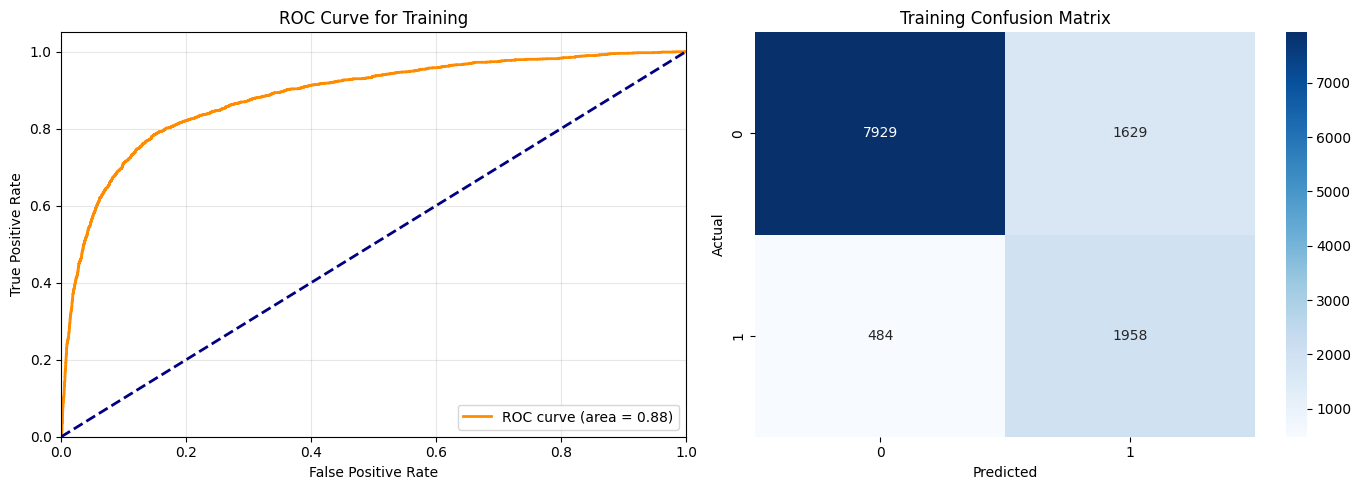

===== Training Results =====
    AUROC: 0.8839
    F1 Score: 0.6495
    




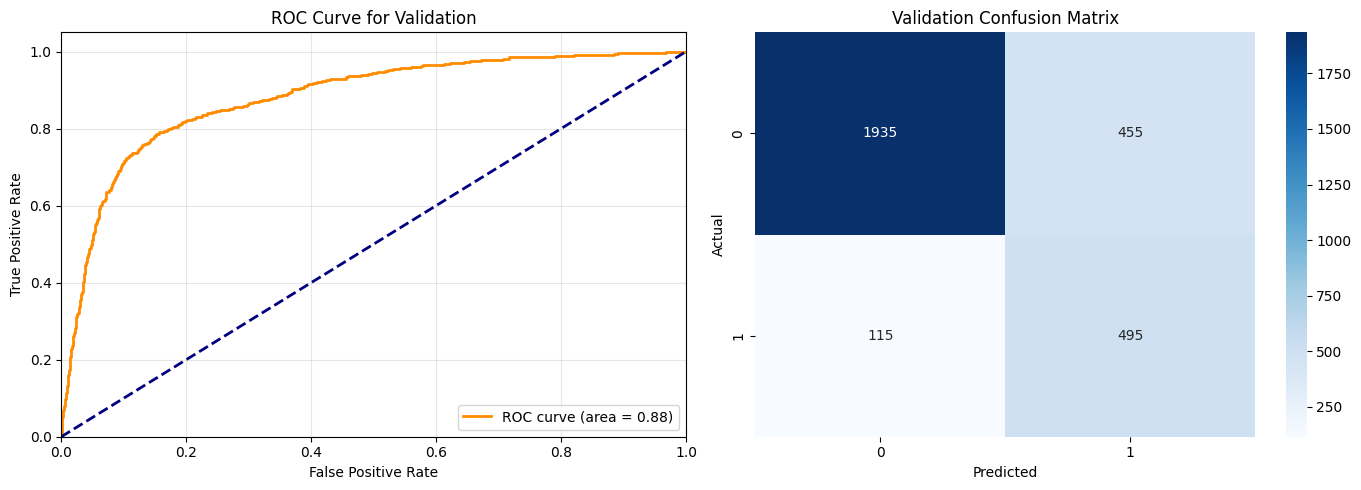

===== Validation Results =====
    AUROC: 0.8800
    F1 Score: 0.6346
    




['log_reg.joblib']

In [7]:
dfs = load_competition_data(competition)

raw_train_df = dfs["train"].set_index("id")
raw_test_df = dfs["test"].set_index("id")
raw_sample_submission = dfs["sample_submission"]


train_df, val_df = train_test_split(
    raw_train_df,
    test_size=0.20,
    random_state=42,
    stratify=raw_train_df["Exited"]
    )

# Створюємо трен. і вал. набори
input_cols = [
    col for col in train_df.columns
    if col not in ["CustomerId", "Surname", "Exited"]
    ]
target_col = ["Exited"]
print(f"""
input_cols: {input_cols}
target_col : {target_col}
""")

train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include="number").columns.tolist()
categorical_cols = train_inputs.select_dtypes("object").columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
     ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(
        drop = "if_binary",
        sparse_output = False,
        handle_unknown = "ignore",
        ))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers = [
        ("numerical", numeric_transformer, numeric_cols),
        ("categorical", categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps =[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state = 42,
        class_weight = "balanced",
        ))
])
model_pipeline.set_output(transform="pandas")

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets.values.ravel())

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=""):
    y_pred = model_pipeline.predict(inputs)
    y_pred_proba = model_pipeline.predict_proba(inputs)[:, 1]

    # ROC curve
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # metrics
    roc_auc = auc(fpr, tpr)
    f1 = f1_score(targets, y_pred)
    cm = confusion_matrix(targets, y_pred)

    # 2 графіки поруч для зручності
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC curve зліва
    axes[0].plot(
        fpr, tpr,
        color="darkorange",
        lw=2,
        label=f"ROC curve (area = {roc_auc:.2f})"
        )
    axes[0].plot(
        [0, 1], [0, 1],
        color="navy",
        lw=2,
        linestyle="--"
        )
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC Curve for {name}")
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)

    # confusion matrix зправа
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[1],
        cbar=True
        )
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    axes[1].set_title(f"{name} Confusion Matrix")

    plt.tight_layout()
    plt.show()

    # Print results
    print(f"""===== {name} Results =====
    AUROC: {roc_auc:.4f}
    F1 Score: {f1:.4f}
    \n\n""")

    return y_pred


# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, "Training")
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, "Validation")

# Зберігаємо модель для подальшого використання
data_to_save = {
    "pipeline": model_pipeline,           # Натренований pipeline (включає preprocessor + classifier)
    "input_cols": input_cols,             # Оригінальні назви колонок
    "target_col": target_col,             # Таргет колонка
    "train_inputs": train_inputs,         # Тренувальні дані (input)
    "train_targets": train_targets,       # Тренувальні дані (target)
    "val_inputs": val_inputs,             # Валідаційні дані (input)
    "val_targets": val_targets,           # Валідаційні дані (target)
    "numeric_cols": numeric_cols,         # Числові колонки
    "categorical_cols": categorical_cols  # Категоріальні колонки
}

joblib.dump(data_to_save, 'log_reg.joblib')

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

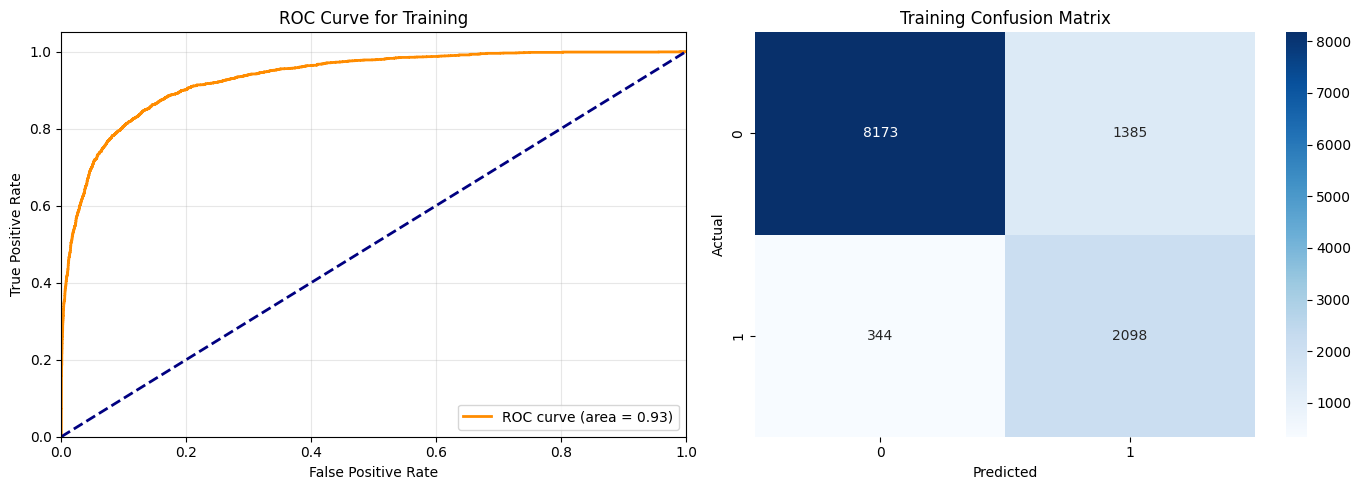

===== Training Results =====
    AUROC: 0.9331
    F1 Score: 0.7082
    




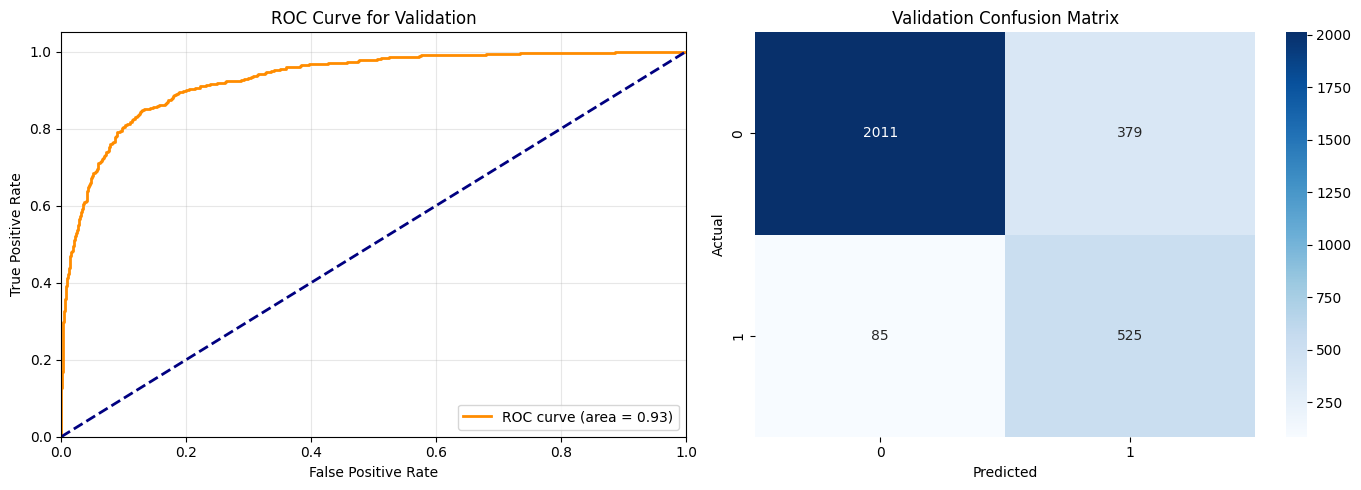

===== Validation Results =====
    AUROC: 0.9291
    F1 Score: 0.6935
    




['poly_log_reg.joblib']

In [8]:
poly_features = PolynomialFeatures(degree=2)

classifier_ = LogisticRegression(
        random_state = 42,
        max_iter = 1000,
        class_weight = "balanced",
        # penalty = "l1", # експериментувала з регуляризацією для Kaggle submission
        # solver = "saga", # експериментувала з регуляризацією для Kaggle submission
        # C = 0.1, # експериментувала з регуляризацією для Kaggle submission
    )

poly_model_pipeline = Pipeline(steps=[
    ("preprocesso", preprocessor),
    ("polynomial_features", poly_features),
    ("classifier", classifier_)
])
poly_model_pipeline.set_output(transform="pandas")

poly_model_pipeline.fit(train_inputs, train_targets.values.ravel())

# Оцінюємо модель на трен і вал даних
poly_train_preds = predict_and_plot(poly_model_pipeline, train_inputs, train_targets, 'Training')
poly_val_preds = predict_and_plot(poly_model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
poly_data_to_save = {
    "pipeline": poly_model_pipeline,
    "input_cols": input_cols,
    "target_col": target_col,
    "train_inputs": train_inputs,
    "train_targets": train_targets,
    "val_inputs": val_inputs,
    "val_targets": val_targets,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols
}

joblib.dump(poly_data_to_save, "poly_log_reg.joblib")

Добре генералізує, бо різниця на тренувальному та валідаційному наборах невеличка

In [9]:
# FOR KAGGLE
def predict_raw_df(
    pipeline,
    input_df: pd.DataFrame
    ):
    input_cols_filtered = [
        col for col in input_df.columns
        if col not in ["CustomerId", "Surname", "Exited"]
    ]
    X_input = input_df[input_cols_filtered]

    prob = pipeline.predict_proba(X_input)[:, 1]
    return prob

test_raw_df = raw_test_df

test_preds = predict_raw_df(poly_model_pipeline, test_raw_df)
# test_preds

submission = raw_sample_submission
submission["Exited"] = test_preds
submission.head()

submission.to_csv("submission_log_reg.csv", index=False)

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

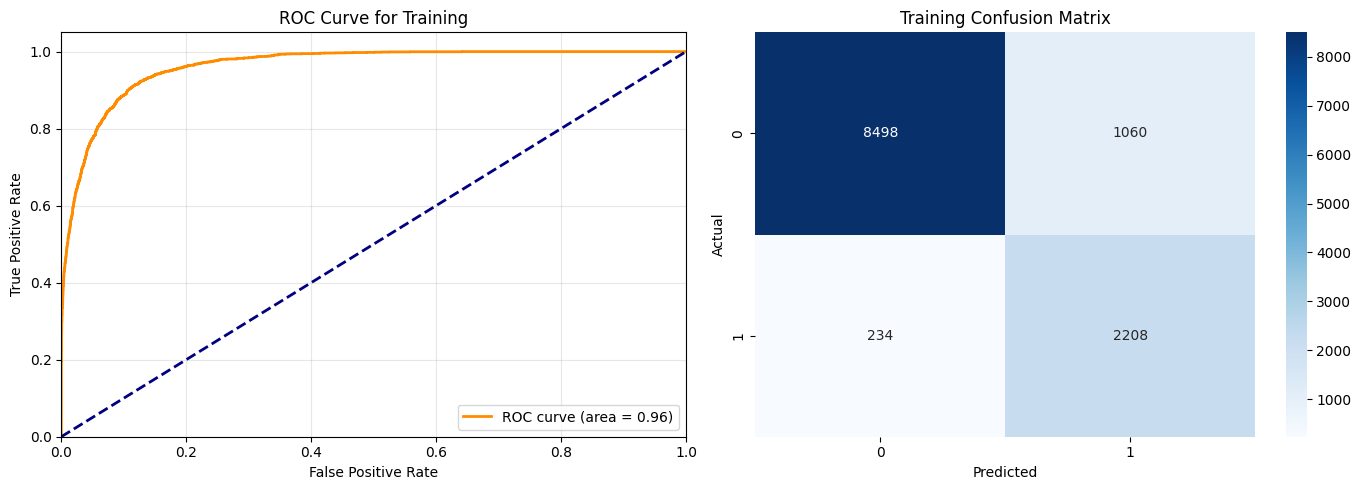

===== Training Results =====
    AUROC: 0.9623
    F1 Score: 0.7734
    




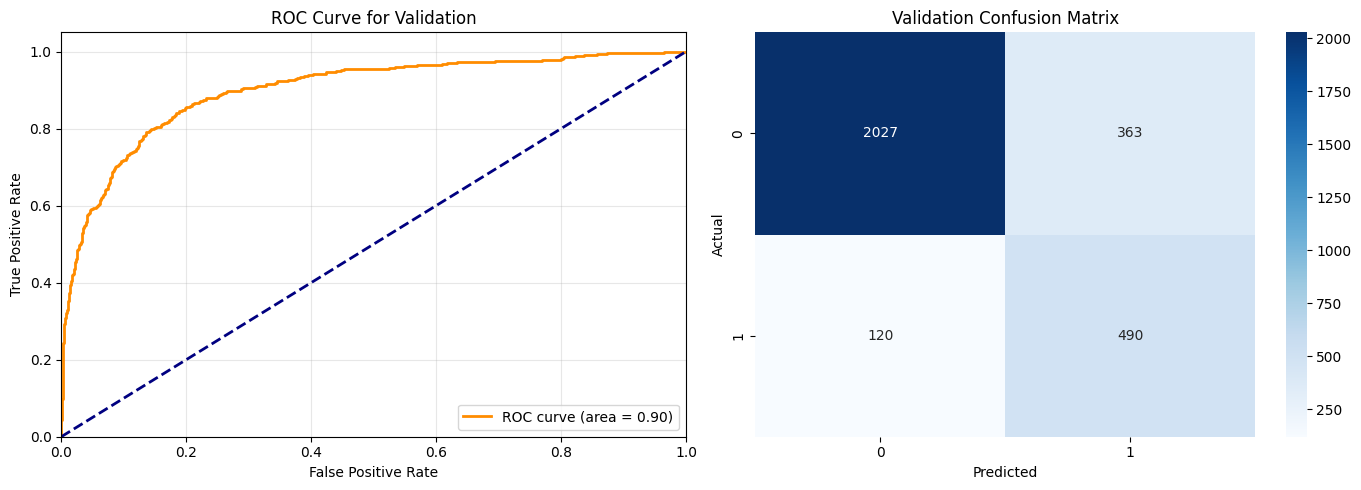

===== Validation Results =====
    AUROC: 0.8993
    F1 Score: 0.6699
    




['poly_4_log_reg.joblib']

In [10]:
poly_features_4 = PolynomialFeatures(degree=4)

classifier_4 = LogisticRegression(
        random_state = 42,
        class_weight = "balanced",
        max_iter = 1000,
    )

poly_model_pipeline_4 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("polynomial_features", poly_features_4),
    ("classifier", classifier_4)
])
poly_model_pipeline_4.set_output(transform="pandas")

poly_model_pipeline_4.fit(train_inputs, train_targets.values.ravel())

# Оцінюємо модель на трен і вал даних
poly_train_preds = predict_and_plot(poly_model_pipeline_4, train_inputs, train_targets, "Training")
poly_val_preds = predict_and_plot(poly_model_pipeline_4, val_inputs, val_targets, "Validation")

# Зберігаємо модель для подальшого використання
poly_4_data_to_save = {
    "pipeline": poly_model_pipeline_4,
    "input_cols": input_cols,
    "target_col": target_col,
    "train_inputs": train_inputs,
    "train_targets": train_targets,
    "val_inputs": val_inputs,
    "val_targets": val_targets,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols
}

joblib.dump(poly_4_data_to_save, "poly_4_log_reg.joblib")

# Tasks 4-5

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [11]:
regression_data_path = '/content/drive/MyDrive/Colab Notebooks/ML for People/Data/regression_data.csv'
regression_data_df = pd.read_csv(regression_data_path)

regression_train_df, regression_test_df = train_test_split(
    regression_data_df,
    test_size = 0.20,
    random_state = 42
    )

X_train = regression_train_df.iloc[:, :-1]
y_train = regression_train_df["target"]

X_test = regression_test_df.iloc[:, :-1]
y_test = regression_test_df["target"]

In [12]:
# degree_ls = [i for i in range(6)]

regression_model_pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("polynomial_features", PolynomialFeatures(degree=5, include_bias=False)),
        ("regression", LinearRegression())
      ])

regression_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('polynomial_features',
                 PolynomialFeatures(degree=5, include_bias=False)),
                ('regression', LinearRegression())])

In [13]:
y_train_pred = regression_model_pipeline.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_pred_test = regression_model_pipeline.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))


print(f"""
TRAIN:
R2  = {r2_train:.4f}
RMSE= {rmse_train:.4f}

TEST:
R2  = {r2_test:.4f}
RMSE= {rmse_test:.4f}
""")


TRAIN:
R2  = 1.0000
RMSE= 0.0000

TEST:
R2  = 0.4559
RMSE= 35.6281



Ця модель перенавчилась, вона показує погані результати на тестовому і гарні на тренувальному. Вона заскладна для тої кількості даних та фіч, що є.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(
        alpha=1.0,
        max_iter=5000
    ),
    "Lasso": Lasso(
        alpha=1.0,
        max_iter=5000
    ),
    "ElasticNet": ElasticNet(
        alpha=1.0,
        l1_ratio=0.5,
        max_iter=5000
    ),
}

for name, model in models.items():
    regression_model_pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("polynomial_features", PolynomialFeatures(degree=20, include_bias=False)),
        ("regression", model)
      ])
    regression_model_pipeline.fit(X_train, y_train)

    y_train_pred = regression_model_pipeline.predict(X_train)
    y_test_pred = regression_model_pipeline.predict(X_test)

    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    print(f"""
=========== {name} ===========
TRAIN:
R2  = {r2_train:.4f}
RMSE= {rmse_train:.4f}

TEST:
R2  = {r2_test:.4f}
RMSE= {rmse_test:.4f}
""")


=========== Linear Regression ===========
TRAIN:
R2  = 0.9995
RMSE= 1.0081

TEST:
R2  = -428158801158.7693
RMSE= 31605735.6810


=========== Ridge ===========
TRAIN:
R2  = 0.4883
RMSE= 31.5717

TEST:
R2  = -15796213.7369
RMSE= 191972.9243



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.340e+03, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(



=========== Lasso ===========
TRAIN:
R2  = 0.9974
RMSE= 2.2495

TEST:
R2  = -0.6197
RMSE= 61.4731


=========== ElasticNet ===========
TRAIN:
R2  = 0.9572
RMSE= 9.1264

TEST:
R2  = -449.6743
RMSE= 1025.4036



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.062e+03, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(


Жахливо виглядає з 20 степенем :D

більш-менш Lasso впорався, бо він може давати 0 як множник ознакам, тому він потер багато непотрібних.

А так цікаво для якої кількості даних/фіч можна поліном 20 степеню брати, мабуть на таких задачах краще вже одразу брати якісь нейромережі, чи буває необхідність?

In [15]:
# Я вичитала, що більші альфа можуть змінити картинку, цікаво, спробувала на alphas = [5, 10, 100, 500], але результат тільки гірший на цьому наборі з цим поліномом